<a href="https://colab.research.google.com/github/napat-sri/airflow-training-lab/blob/main/E36_Data_Eng_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Capstone Project
### การจัดการข้อมูลอุบัติเหตุทางการบินทั่วโลก เพื่อวิเคราะห์แนวโน้มความปลอดภัย

**ชื่อ-นามสกุล:** นายณภัทร ศรีวิโรจน์  
**รหัส** E36  
**หน่วยงาน:** ศูนย์ซอฟต์แวร์กองทัพอากาศ



## Phase 0 - Data Collection

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read the dataset
original_df = pd.read_csv("data/Airplane_Crashes_and_Fatalities_Since_1908_20190820105639.csv")
df = original_df.copy()

In [3]:
# Data Insight

print("Dataset shape:", df.shape)
print("\nColumns: ", df.columns.tolist())

print("\nFirst 5 records: ")
display(df.head())

Dataset shape: (4967, 17)

Columns:  ['Date', 'Time', 'Location', 'Operator', 'Flight #', 'Route', 'AC Type', 'Registration', 'cn/ln', 'Aboard', 'Aboard Passangers', 'Aboard Crew', 'Fatalities', 'Fatalities Passangers', 'Fatalities Crew', 'Ground', 'Summary']

First 5 records: 


,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,09/07/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,07/12/1912,06:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...


## Phase 1 - Data Cleaning

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4967 entries, 0 to 4966
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   4967 non-null   str    
 1   Time                   3457 non-null   str    
 2   Location               4963 non-null   str    
 3   Operator               4957 non-null   str    
 4   Flight #               1315 non-null   str    
 5   Route                  4192 non-null   str    
 6   AC Type                4952 non-null   str    
 7   Registration           4694 non-null   str    
 8   cn/ln                  4299 non-null   str    
 9   Aboard                 4949 non-null   float64
 10  Aboard Passangers      4738 non-null   float64
 11  Aboard Crew            4741 non-null   float64
 12  Fatalities             4959 non-null   float64
 13  Fatalities Passangers  4725 non-null   float64
 14  Fatalities Crew        4726 non-null   float64
 15  Ground         

In [5]:
df.describe()

,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground
count,4949.000000,4738.000000,4741.000000,4959.000000,4725.000000,4726.000000,4926.000000
mean,31.088301,26.898691,4.479646,22.338173,19.017566,3.579348,1.728177
std,45.438282,44.010591,3.489021,35.026176,34.114849,3.170223,55.708966
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,3.000000,2.000000,4.000000,1.000000,2.000000,0.000000
50%,16.000000,12.000000,4.000000,11.000000,8.000000,3.000000,0.000000
75%,35.000000,30.000000,6.000000,25.000000,21.000000,5.000000,0.000000
max,644.000000,614.000000,61.000000,583.000000,560.000000,46.000000,2750.000000


### 1. Missing values

In [6]:
# Count missing values
missing = df.isnull().sum()
missing_percent = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "Missing count: ": missing,
    "Missing %: ": missing_percent
})

print(missing_report)

                       Missing count:   Missing %: 
Date                                 0         0.00
Time                              1510        30.40
Location                             4         0.08
Operator                            10         0.20
Flight #                          3652        73.53
Route                              775        15.60
AC Type                             15         0.30
Registration                       273         5.50
cn/ln                              668        13.45
Aboard                              18         0.36
Aboard Passangers                  229         4.61
Aboard Crew                        226         4.55
Fatalities                           8         0.16
Fatalities Passangers              242         4.87
Fatalities Crew                    241         4.85
Ground                              41         0.83
Summary                             64         1.29


In [7]:
# High missings percentage
high_missing = ['Flight #', 'Route', 'cn/ln']

for c in high_missing:
  if c in df.columns:
    df[c] = df[c].fillna("Unknown")
    print(f"fill 'Unknown' in {c}")

fill 'Unknown' in Flight #
fill 'Unknown' in Route
fill 'Unknown' in cn/ln


In [8]:
# Time missing (Unknown exact time)
df['Time'] = df['Time'].fillna('00:00')
print("fill '00:00' in Time")

fill '00:00' in Time


In [9]:
# 'Ground' missings -> 0
df['Ground'] = pd.to_numeric(df['Ground']).fillna(0)
print("fill '0' in Ground")

fill '0' in Ground


In [10]:
# 'Aboard' / 'Fatalities' -> less missings
for c in ['Aboard', 'Fatalities']:
  if c in df.columns:
    df[c] = pd.to_numeric(df[c])
    med_val = df[c].median()
    df[c] = df[c].fillna(med_val)
    print(f"fill 'median' in {c}")

fill 'median' in Aboard
fill 'median' in Fatalities


In [11]:
# 'Summary' missing (No summary available)
df['Summary'] = df['Summary'].fillna('No summary available')
print("fill 'No summary' in Summary")

fill 'No summary' in Summary


In [12]:
# Missing main values (Date/Location)
df.dropna(subset=['Date', 'Location'], inplace=True)
print("drop rows that missing Date/Location")

drop rows that missing Date/Location


In [13]:
# Missing values in 'Operator' -> fill with 'Unknown'
df['Operator'] = df['Operator'].fillna('Unknown')
print("fill 'Unknown' in Operator")

fill 'Unknown' in Operator


In [14]:
df.dropna()
df2 = df.drop(columns=['Aboard Passangers', 'Aboard Crew', 'Fatalities Passangers', 'Fatalities Crew'])
display(df2)

,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,Unknown,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,09/07/1909,00:00,"Juvisy-sur-Orge, France",Unknown,Unknown,Air show,Wright Byplane,SC1,Unknown,1.0,1.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,07/12/1912,06:30,"Atlantic City, New Jersey",Military - U.S. Navy,Unknown,Test flight,Dirigible,NaN,Unknown,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,08/06/1913,00:00,"Victoria, British Columbia, Canada",Private,Unknown,Unknown,Curtiss seaplane,NaN,Unknown,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,09/09/1913,18:30,Over the North Sea,Military - German Navy,Unknown,Unknown,Zeppelin L-1 (airship),NaN,Unknown,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4962,04/16/2019,11:00,"Puerto Montt, Chile",Archipelagos Service Aereos,Unknown,Puerto Montt - Ayacara,Pilatus-Britten Norman BN-2B-27 Islander,CC-CYR,2169,6.0,6.0,0.0,"While the aircraft was in the initial climb, p..."
4963,05/05/2019,18:30,"Near Monclava, Mexico",TVPX Aircraft Solutions,Unknown,Las Vegas - Monterrey,Canadair CL-600-2B16-Challenger,N601VH,5043,13.0,13.0,0.0,The aircraft crashed while en route on a retur...
4964,05/05/2019,18:30,"Moscow, Russia",Aeroflot Russian International Airlines,Unknown,Moscow - Murmansk,Sukhoi Superjet-100-95B,RA-89098,95135,78.0,41.0,0.0,Forty-five minutes after taking off from Mosco...
4965,06/03/2019,13:00,"Near Lipo, India",Military - Indian Air Force,Unknown,Jorhat-Rowriah - Mechuka,Antonov An-32,K2752,1009,13.0,13.0,0.0,Crashed about 34km WNW of Mechuka.


In [15]:
# Operator
df2["Operator"] = (df2["Operator"].astype(str).str.strip().str.title())
    
# Group military operator in different spelling
military_map = {
    "Military - U.S. Air Force": "US Air Force",
    "Military - Usaf"          : "US Air Force",
    "U.S. Air Force"           : "US Air Force",
    "Military - U.S. Army"     : "US Army",
    "Military - U.S. Navy"     : "US Navy",
}
df2["Operator"] = df2["Operator"].replace(military_map)
print(f"   Operator: {df2['Operator'].nunique()} unique values")

   Operator: 2231 unique values


In [16]:
# Location
df2["Location"] = df2["Location"].astype(str).str.strip().str.title()
print(f"   Location: {df2['Location'].nunique()} unique values")

   Location: 4090 unique values


In [17]:
# Aircraft Type
df2["AC Type"] = df2["AC Type"].astype(str).str.strip().str.title()
print(f"   Type: {df2['AC Type'].nunique()} unique aircraft types")

   Type: 2385 unique aircraft types


### 2. Duplicate Data

In [18]:
dup_count = df2.duplicated().sum()
print("Duplicate counts: ", dup_count)

Duplicate counts:  0


### 3. Outliers

In [19]:
mask = df2["Fatalities"] > df2['Aboard']
df2.loc[mask, "Fatalities"] = df2.loc[mask, "Aboard"]
print(mask)
print(f"\n   Edit {mask.sum()} records that Fatalities > Aboard")

0       False
1       False
2       False
3       False
4       False
        ...  
4962    False
4963    False
4964    False
4965    False
4966    False
Length: 4963, dtype: bool

   Edit 1 records that Fatalities > Aboard


### 4. Data Visualization

In [20]:
display(df2.head())

,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",US Army,Unknown,Demonstration,Wright Flyer Iii,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,09/07/1909,00:00,"Juvisy-Sur-Orge, France",Unknown,Unknown,Air show,Wright Byplane,SC1,Unknown,1.0,1.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,07/12/1912,06:30,"Atlantic City, New Jersey",US Navy,Unknown,Test flight,Dirigible,NaN,Unknown,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,08/06/1913,00:00,"Victoria, British Columbia, Canada",Private,Unknown,Unknown,Curtiss Seaplane,NaN,Unknown,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,09/09/1913,18:30,Over The North Sea,Military - German Navy,Unknown,Unknown,Zeppelin L-1 (Airship),NaN,Unknown,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...


#### 4.1 Feature Engineering

In [21]:
# datetime
df2['Date'] = pd.to_datetime(df2.Date)

df2['Year'] = df2['Date'].dt.year
df2['Month'] = df2['Date'].dt.month
df2['Decade'] = (df2['Year'] // 10 * 10).astype(str) + "s"

In [22]:
# Survival Rate
df2["Survivors"] = (df2['Aboard'] - df2['Fatalities']).clip(lower=0)
df2["Survival_Rate"]  = (df2["Survivors"] / df2["Aboard"].replace(0, np.nan)).round(2)
df2["Fatality_Rate"]  = (df2["Fatalities"] / df2["Aboard"].replace(0, np.nan)).round(2)

In [23]:
# Country
df2["Country"] = df2["Location"].str.split(",").str[-1].str.strip()
df2['Country']  = df2['Country'].fillna('Unknown')

In [24]:
print("Datashape: ", df2.shape)
display(df2.head())

Datashape:  (4963, 20)


,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Fatalities,Ground,Summary,Year,Month,Decade,Survivors,Survival_Rate,Fatality_Rate,Country
0,1908-09-17,17:18,"Fort Myer, Virginia",US Army,Unknown,Demonstration,Wright Flyer Iii,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly...",1908,9,1900s,1.0,0.5,0.5,Virginia
1,1909-09-07,00:00,"Juvisy-Sur-Orge, France",Unknown,Unknown,Air show,Wright Byplane,SC1,Unknown,1.0,1.0,0.0,Eugene Lefebvre was the first pilot to ever be...,1909,9,1900s,0.0,0.0,1.0,France
2,1912-07-12,06:30,"Atlantic City, New Jersey",US Navy,Unknown,Test flight,Dirigible,NaN,Unknown,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...,1912,7,1910s,0.0,0.0,1.0,New Jersey
3,1913-08-06,00:00,"Victoria, British Columbia, Canada",Private,Unknown,Unknown,Curtiss Seaplane,NaN,Unknown,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...,1913,8,1910s,0.0,0.0,1.0,Canada
4,1913-09-09,18:30,Over The North Sea,Military - German Navy,Unknown,Unknown,Zeppelin L-1 (Airship),NaN,Unknown,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...,1913,9,1910s,6.0,0.3,0.7,Over The North Sea


In [25]:
# Save cleaned data to csv
df2.to_csv("airplane_crashes_cleaned.csv")
print("CSV Saved")

CSV Saved


#### 4.2 Visualization

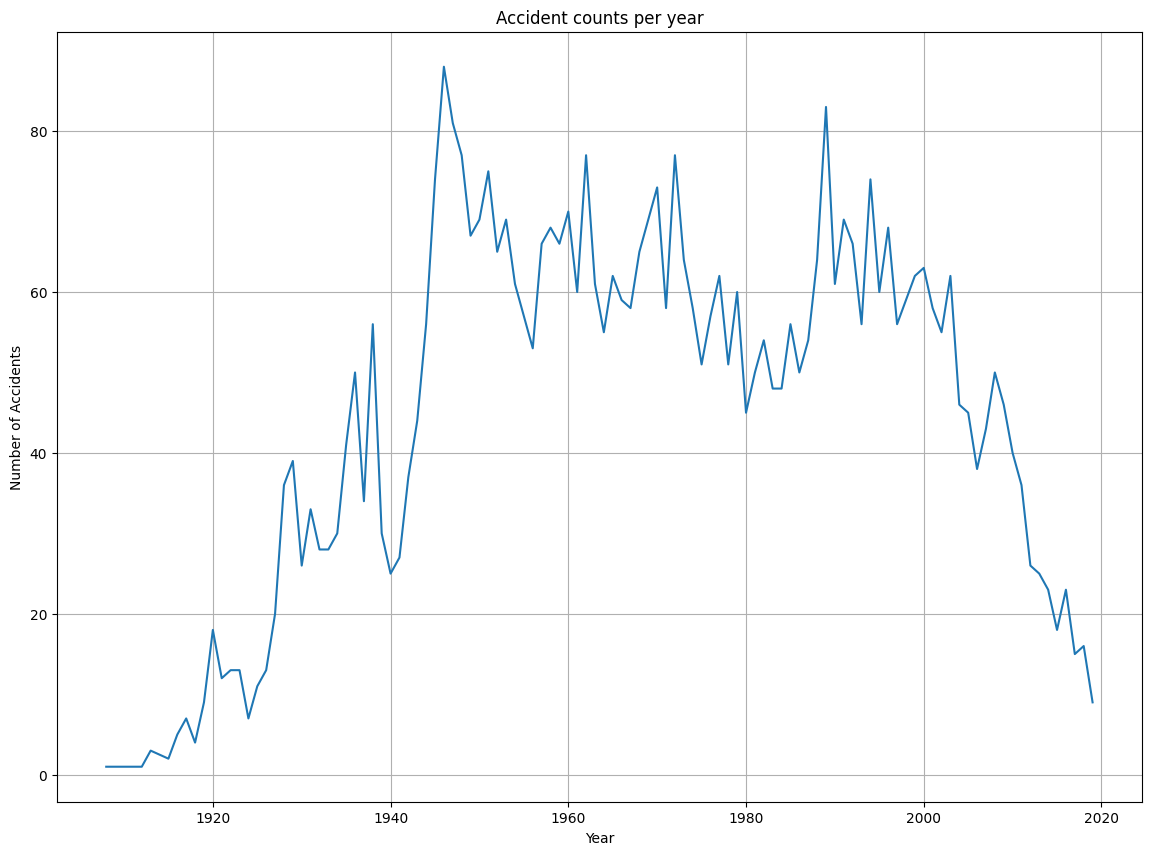

In [26]:
# accidents per year

accident_group = df2.groupby('Year', as_index=False).size()
#accident_group

plt.figure(figsize=(14, 10))
plt.grid(True)
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.title("Accident counts per year")
plt.plot(
    accident_group['Year'],
    accident_group['size']
)
plt.show()

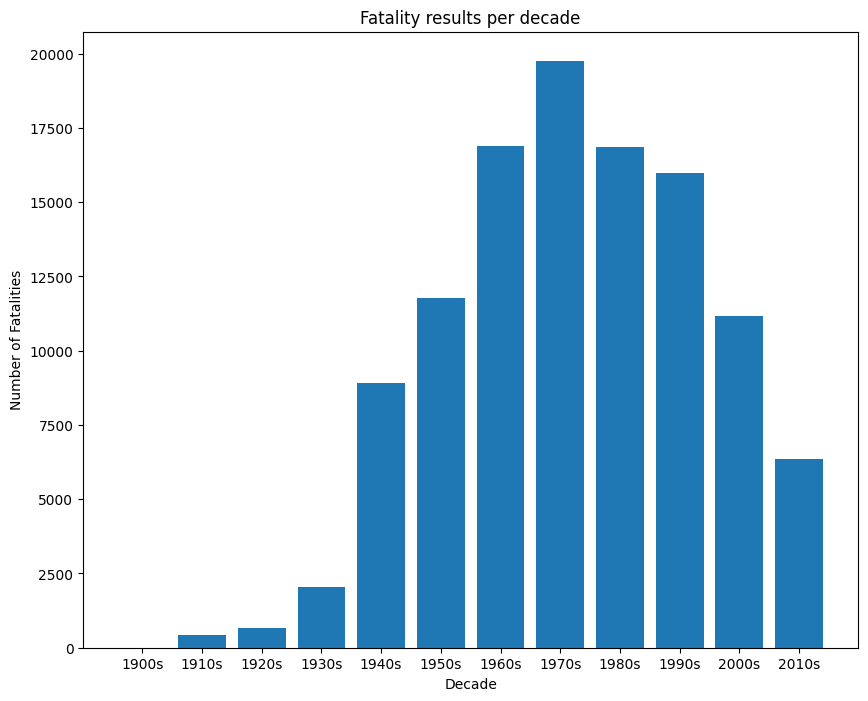

In [27]:
# fatalities per decade

fatal_decade = df2.groupby('Decade', as_index=False)['Fatalities'].sum()
#fatal_decade

plt.figure(figsize=(10, 8))
plt.xlabel("Decade")
plt.ylabel("Number of Fatalities")
plt.title("Fatality results per decade")
plt.bar(
    fatal_decade['Decade'],
    fatal_decade['Fatalities']
)
plt.show()

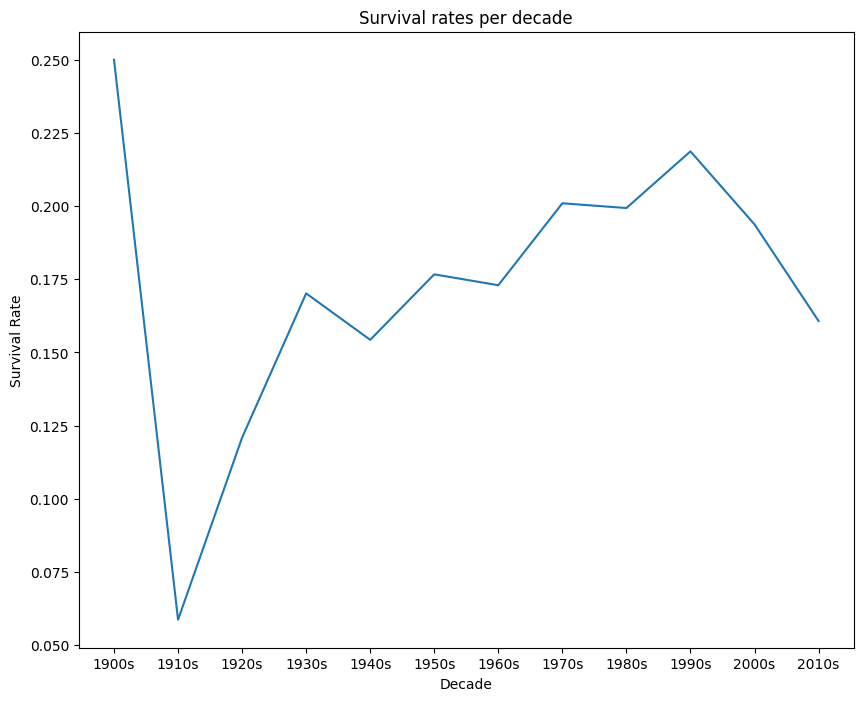

In [28]:
# survival rate per decade

survive_decade = df2.groupby('Decade', as_index=False)['Survival_Rate'].mean()
#survive_decade

plt.figure(figsize=(10, 8))
plt.xlabel("Decade")
plt.ylabel("Survival Rate")
plt.title("Survival rates per decade")
plt.plot(
    survive_decade['Decade'],
    survive_decade['Survival_Rate']
)
plt.show()

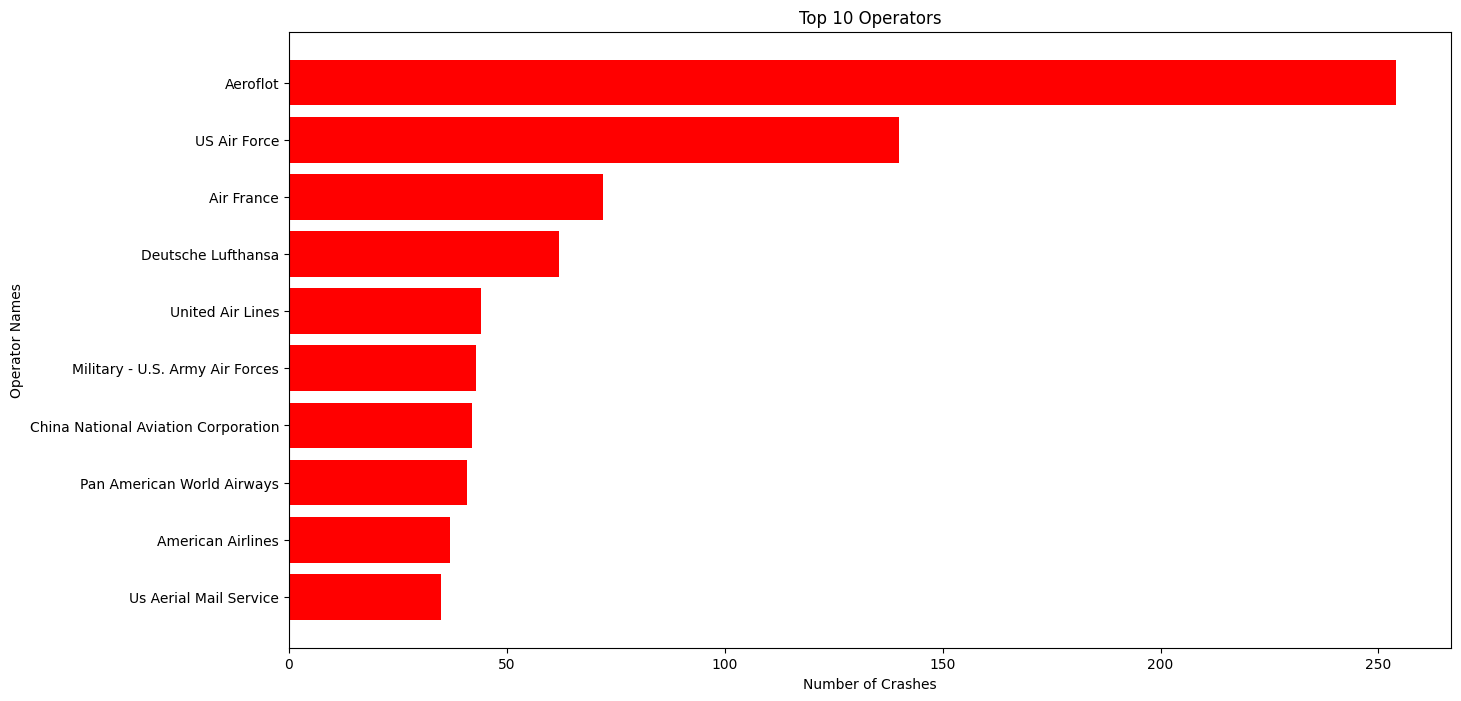

In [29]:
top_operators = (
    df2.groupby("Operator")
    .size()
    .reset_index(name="Crashes")
    .sort_values("Crashes", ascending=False)
    .head(10)
)
# top_operators

plt.figure(figsize=(15, 8))
plt.xlabel("Number of Crashes")
plt.ylabel("Operator Names")
plt.title("Top 10 Operators")
plt.barh(
    top_operators['Operator'],
    top_operators['Crashes'],
    color='red')
plt.gca().invert_yaxis()
plt.show()

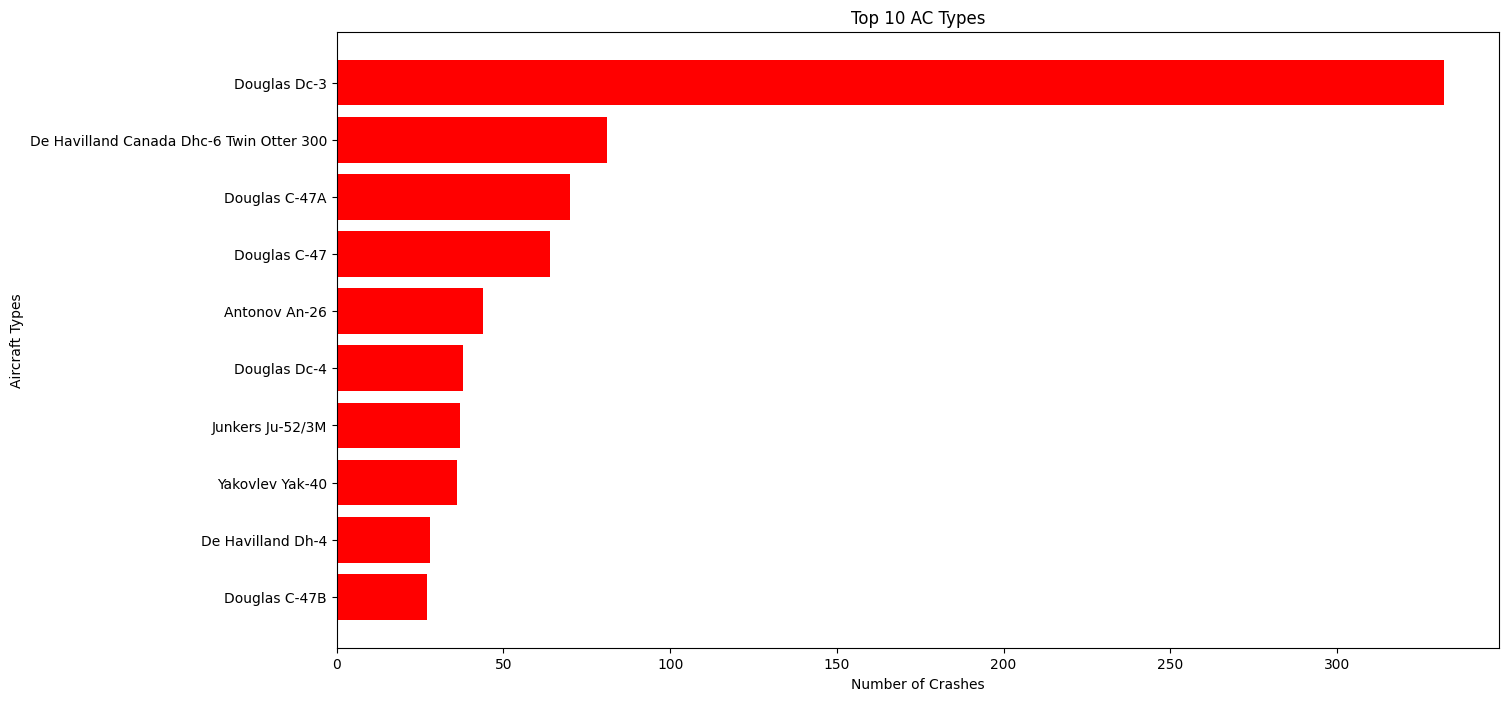

In [30]:
top_ac_type = (
    df2.groupby("AC Type")
    .size()
    .reset_index(name="Crashes")
    .sort_values("Crashes", ascending=False)
    .head(10)
)
# top_operators

plt.figure(figsize=(15, 8))
plt.xlabel("Number of Crashes")
plt.ylabel("Aircraft Types")
plt.title("Top 10 AC Types")
plt.barh(
    top_ac_type['AC Type'],
    top_ac_type['Crashes'],
    color='red')
plt.gca().invert_yaxis()
plt.show()